In [2]:
import xarray as xr
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')

In [3]:
ds1 = xr.open_dataset('../data/ensemble_1871.nc')
models = ds1.esm.values
ds1.close()

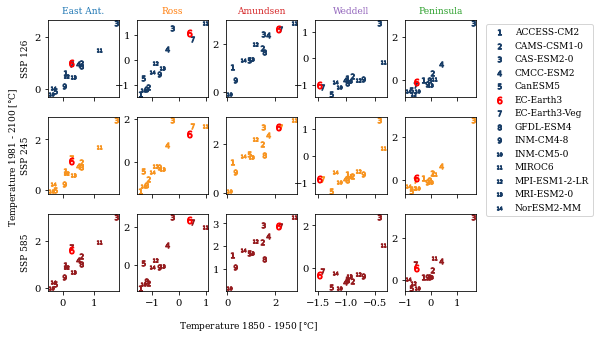

In [4]:
ssps = ['126','245','585']
scol = {}
scol['126'] = (23/255,60/255,102/255)
scol['245'] = (247/255,148/255,32/255)
scol['585'] = (149/255,27/255,30/255)
basinname = ['East Ant.','Ross','Amundsen','Weddell','Peninsula']
bcol = {}
bcol['East Ant.'] = 'tab:blue'
bcol['Ross']      = 'tab:orange'
bcol['Amundsen']  = 'tab:red'
bcol['Weddell']   = 'tab:purple'
bcol['Peninsula'] = 'tab:green'

markers = ['$1$','o','v','^','<','>','1','2','3','4','s','D','d','*']

plt.style.use('../src/style_paper')
mpl.rc('figure.subplot',wspace=.25,hspace=.25)

fig,ax = plt.subplots(3,5,figsize=(7,5),sharex='col')

for s,ssp in enumerate(ssps):

    ds1 = xr.open_dataset(f'../data/eveline/thetao_sector_timeseries_historical+ssp{ssp}_1850_2100.nc')

    for b,basin in enumerate(['eais','ross','amun','wedd','apen']):
        for m,model in enumerate(models):
            Thist = np.mean(ds1.sel(model=model)[basin].values[:100])
            Tfut = np.mean(ds1.sel(model=model)[basin].values[-21:-1])
            if model=='EC-Earth3':
                ax[s,b].scatter(Thist,Tfut,50,color='r',marker=f'${m+1}$',label=model,zorder=10)
            else:
                ax[s,b].scatter(Thist,Tfut,30,color=scol[ssp],marker=f'${m+1}$',label=model)
        if s==0:
            ax[s,b].set_title(basinname[b],c=bcol[basinname[b]])
    ds1.close()
    ax[s,0].set_ylabel(f'SSP {ssp}')

ax[0,-1].legend(loc='upper right', bbox_to_anchor=(2.7,1))

fig.supylabel('Temperature 1981 - 2100 [$\degree$C]')
fig.supxlabel('Temperature 1850 - 1950 [$\degree$C]')

plt.savefig('../draftfigs/esm_intercomp.png')

plt.show()